# Serving Your Portfolio Model with FastAPI

FastAPI is a modern async web framework that auto-generates OpenAPI documentation and validates requests using Pydantic. This notebook wraps a FastAPI service around **the portfolio model you exported from AIAT 114 or AIAT 122** — the same artifact Unit 1 served — and tests it in-notebook using `TestClient`, no uvicorn process required.

Because the model is fixed across the Flask lesson, this one and the Docker lesson, every difference you observe is a property of the *serving layer*, not of the model.

## 🔗 Where this fits

**Builds on:** Course 08 (AIAT 122) — Unit 5, lesson 06 "06 Flask and FastAPI Deployment" — that lesson got a prediction out of an endpoint; here the point is everything around the prediction — Pydantic rejecting a malformed request before your model ever sees it, and the OpenAPI page generated from that same schema.

**Used later in:** Course 12 (AIAT 126) — Unit 5, lesson 01 "Project Documentation and Presentation", whose deliverable checklist asks for live-demo setup instructions and screenshots of the deployed system.


## 📰 Ariane 5, and the danger of a constraint inherited from somewhere else

On **4 June 1996** the maiden flight of Ariane 5 was destroyed about **37 seconds** after launch. The cause was a conversion inside the inertial reference software: a 64-bit floating-point horizontal-velocity value being written into a **16-bit signed integer**, which overflows above 32,767. The code was correct — for Ariane 4. Its trajectory never produced values that large, so the developers had deliberately left three of seven variables unprotected to stay inside a CPU budget. Ariane 5 flew a different profile, the value went out of range, the exception propagated, and the rocket destroyed itself. The inquiry board's finding was not "a programmer made a mistake"; it was that a **range assumption valid in one deployment was carried unexamined into another**.

Keep that in mind when you reach section 3, where this notebook explicitly refuses to put `Field(..., ge=0)` on the generated fields. A tutorial can write `ge=0` because petals cannot be negative. Your model's features may be standardized, signed PCA components, or engineered ratios — and a constraint you cannot justify for every deployment is exactly the Ariane 5 bug, waiting.

**What goes wrong without this lesson.** Hand-typed schemas encode assumptions twice: once in the model, once in the API, and they drift apart. Retrain with one extra feature and the API keeps advertising the old contract, validating requests perfectly against a model that no longer exists. Generating the schema *from the card* means there is only one place the truth lives.

## Learning Objectives

By the end of this notebook you will be able to:
1. Explain FastAPI's key advantages over Flask (auto-docs, Pydantic, async support)
2. Generate request/response schemas from `model_card.json` rather than hard-coding field names
3. Build FastAPI endpoints for `/predict`, `/health`, and `/model-info` that report the *real* deployed model
4. Test a FastAPI app in-notebook using `TestClient`
5. Decide when to choose FastAPI vs Flask

> Need a portfolio model? See [`../../PORTFOLIO_MODEL.md`](../../PORTFOLIO_MODEL.md). Without one, this notebook serves the named fallback `wdbc-baseline` and says so in its output.

## 1. Install Dependencies

In [1]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "httpx", "-q"], check=True)
print("httpx ready (required by TestClient)")

httpx ready (required by TestClient)



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


## 2. Load the Portfolio Model

No training happens in this lesson — the model arrived finished. We load the artifact and its card, exactly as Unit 1 did.

In [2]:
# WHAT: load YOUR portfolio model - the same artifact Unit 1 served.
# WHY: one model, several serving layers. Because the artifact does not change
# between the Flask lesson, this one, and the Docker lesson, every difference you
# observe is the serving layer, not the model. See Course 11/PORTFOLIO_MODEL.md.
import json
import sys
from pathlib import Path

# --- Find Course 11 from ANY working directory, and on Google Colab. -----------------
# WHAT: locate the folder holding portfolio_model.py, then put it on sys.path.
# WHY:  walking up from the current folder alone only works when the kernel happened to
#       start inside Course 11. Open this notebook from the repository root, or from a
#       file browser sitting somewhere else, and that walk finds nothing. This checks
#       every ancestor AND its "Course 11" subfolder, then - on Colab, where there is no
#       repository at all - downloads the module so cell one still runs.
_here = Path.cwd().resolve()
COURSE11 = next((_p for _c in [_here, *_here.parents]
                 for _p in (_c, _c / "Course 11")
                 if (_p / "portfolio_model.py").exists()), None)
if COURSE11 is None:                      # Google Colab, or a stray copy of the notebook
    import urllib.request
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/AI-Diploma-Program/"
            "main/Course%2011/portfolio_model.py", "portfolio_model.py")
    except Exception as _e:
        raise FileNotFoundError(
            "Could not find portfolio_model.py from this folder, and could not download "
            "it either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    COURSE11 = Path.cwd()

if str(COURSE11) not in sys.path:
    sys.path.insert(0, str(COURSE11))
# -------------------------------------------------------------------------------------

import portfolio_model as pf

# Falls back to the named 'wdbc-baseline' model if you have not exported one yet.
model, card = pf.load_portfolio_model()
MODEL_DIR = pf.portfolio_dir()


FALLBACK MODEL 'wdbc-baseline' — this is NOT your model.
  directory   : /Users/abdullah/ai-diploma-portfolio
  artifact    : model.joblib  (sklearn)
  task        : classification  ->  2 classes ['malignant', 'benign']
  features    : 30 (first three: ['mean radius', 'mean texture', 'mean perimeter'])
  accuracy    : 0.9825 on held-out 20% (random_state=42, stratified)
  Export your own model from AIAT 114 or AIAT 122 and re-run: see Course 11/PORTFOLIO_MODEL.md


## 3. Pydantic Schemas — Generated From the Model Card

Pydantic models describe the **shape** of request and response data. FastAPI uses them to:
- Automatically validate incoming JSON (wrong type or missing field → 422 Unprocessable Entity)
- Generate the OpenAPI schema that powers `/docs`
- Serialize response objects to JSON

The catch: typing the field names by hand ties the API to one model forever. We build the schema at runtime with `pydantic.create_model`, straight from the card's `feature_names`.

> **A note on range constraints.** A tutorial iris API can write `Field(..., ge=0)` because petals cannot be negative. Your model's features may be standardized, signed PCA components, or engineered ratios — for most real feature sets `ge=0` would reject valid requests. So the generated schema validates **types and presence**, which are always true, and leaves range expectations documented in the card. A constraint you cannot justify for every deployment is a bug waiting to happen.

In [3]:
# WHAT: build the request schema from the card instead of typing field names.
# WHY: create_model() makes a real Pydantic class at runtime - one required float
# per feature, in the trained order, with the original column name as its
# description. Retrain with a different feature set and the schema follows.
from pydantic import BaseModel, Field, create_model
from typing import Dict

# schema_fields() maps each training column to a legal JSON field name:
# 'mean radius' -> 'mean_radius'. It refuses to continue if two columns collide.
FIELDS = pf.schema_fields(card)
FIELD_ORDER = [field for field, _ in FIELDS]

PredictRequest = create_model(
    "PredictRequest",
    **{field: (float, Field(..., description=f"training column: {original}"))
       for field, original in FIELDS},
)

class PredictionResponse(BaseModel):
    prediction: str
    class_id: int
    confidence: float
    probabilities: Dict[str, float]

print("Generated request schema with", len(FIELD_ORDER), "fields")
for field, original in FIELDS[:4]:
    print(f"  {field:<28} <- {original!r}")
print(f"  ... and {len(FIELDS) - 4} more")

# Parse the card's real sample row through the generated schema.
sample = PredictRequest(**dict(zip(FIELD_ORDER, card["sample_input"])))
print("\nSample row validated OK ->", list(sample.model_dump().items())[:2], "...")


Generated request schema with 30 fields
  mean_radius                  <- 'mean radius'
  mean_texture                 <- 'mean texture'
  mean_perimeter               <- 'mean perimeter'
  mean_area                    <- 'mean area'
  ... and 26 more

Sample row validated OK -> [('mean_radius', 11.26), ('mean_texture', 19.96)] ...


## 4. Write the FastAPI Application

Notice `async def` on each endpoint. FastAPI runs on an async event loop (ASGI). Async endpoints shine when the handler `await`s on I/O — a database, a feature store, another HTTP service — because one worker can serve other requests while waiting.

**Important catch for ML serving:** a *blocking* call like sklearn's `predict()` inside an `async def` blocks the whole event loop, so it does **not** buy you concurrency and can even hurt it. FastAPI sidesteps this automatically if you declare the endpoint as a plain `def` — it runs that in a threadpool. So for CPU-bound inference, prefer a plain `def`, or offload the heavy call (e.g. `run_in_executor`). We use `async def` here to show the syntax; just don't assume `async` alone makes blocking work concurrent.

The `/model-info` endpoint is new and it matters more than it looks: in an incident, the first question is never "is the box up?" but "**which model is up?**". Because it reads the card, it can answer that — including the embarrassing case where production is still serving the course fallback.

In [4]:
%%writefile /tmp/fastapi_app.py
# WHAT: the full FastAPI service - loader, generated schema, three endpoints.
# WHY: compare it line-for-line with the Flask version: the validation code
# disappeared into the schema, and /docs + OpenAPI come for free. Note that the
# app imports NO course helper - a deployed service depends only on the artifact
# and its card, exactly as in Unit 1 (and exactly as it must inside a container).
import json
import os
import re
from pathlib import Path

import numpy as np
from fastapi import FastAPI
from pydantic import BaseModel, Field, create_model
from typing import Dict

# --- Artifact + card --------------------------------------------------------
MODEL_DIR = Path(os.environ.get("AI_DIPLOMA_PORTFOLIO",
                                str(Path.home() / "ai-diploma-portfolio")))
CARD = json.loads((MODEL_DIR / "model_card.json").read_text())
ARTIFACT = MODEL_DIR / CARD["artifact"]

if CARD["framework"] == "sklearn":
    import joblib
    _model = joblib.load(ARTIFACT)

    def probabilities(rows):
        return np.asarray(_model.predict_proba(rows))

elif CARD["framework"] == "onnx":
    import onnxruntime as ort
    _session = ort.InferenceSession(str(ARTIFACT), providers=["CPUExecutionProvider"])
    _input = _session.get_inputs()[0].name

    def probabilities(rows):
        logits = np.asarray(_session.run(None, {_input: np.asarray(rows, dtype=np.float32)})[0])
        exp = np.exp(logits - logits.max(axis=1, keepdims=True))
        return exp / exp.sum(axis=1, keepdims=True)

else:
    raise RuntimeError(f"This app serves 'sklearn' or 'onnx' artifacts, not {CARD['framework']!r}.")

# --- Schema generated from the card ----------------------------------------
def api_field(name):
    slug = re.sub(r"\W+", "_", str(name).strip().lower()).strip("_")
    return f"f_{slug}" if not slug or slug[0].isdigit() else slug

FIELD_ORDER = [api_field(n) for n in CARD["feature_names"]]

PredictRequest = create_model(
    "PredictRequest",
    **{field: (float, Field(..., description=f"training column: {original}"))
       for field, original in zip(FIELD_ORDER, CARD["feature_names"])},
)

class PredictionResponse(BaseModel):
    prediction: str
    class_id: int
    confidence: float
    probabilities: Dict[str, float]

# --- Endpoints --------------------------------------------------------------
app = FastAPI(
    title=f"{CARD['name']} API",
    description=f"Serving the AIAT 125 portfolio model from {CARD['source_course']}",
    version="1.0.0",
)

@app.get("/health")
async def health():
    return {"status": "ok", "model": CARD["name"]}

@app.get("/model-info")
async def model_info():
    """Answer the question every on-call engineer asks first: what is actually deployed?"""
    return {
        "name": CARD["name"],
        "source_course": CARD["source_course"],
        "framework": CARD["framework"],
        "task": CARD["task"],
        "n_features": len(CARD["feature_names"]),
        "classes": CARD["class_names"],
        "reported_metric": CARD["metric"],
        "is_fallback": bool(CARD.get("is_fallback", False)),
    }

@app.post("/predict", response_model=PredictionResponse)
async def predict(req: PredictRequest):
    row = [getattr(req, field) for field in FIELD_ORDER]
    proba = probabilities([row])[0]
    idx = int(np.argmax(proba))
    return PredictionResponse(
        prediction=CARD["class_names"][idx],
        class_id=idx,
        confidence=round(float(proba[idx]), 4),
        probabilities={name: round(float(p), 4)
                       for name, p in zip(CARD["class_names"], proba)},
    )


Overwriting /tmp/fastapi_app.py


## 5. Test with TestClient

`TestClient` wraps the ASGI app and lets you make HTTP calls synchronously in a notebook — no uvicorn server needed. It uses `httpx` internally.

In [5]:
# WHAT: exercise every endpoint through FastAPI's in-process TestClient.
# WHY: note where the work went - malformed input returns 422 from Pydantic
# WITHOUT a single line of validation code of ours running.
import importlib
import sys

sys.path.insert(0, "/tmp")
import fastapi_app as fmod
importlib.reload(fmod)

# TestClient calls the app in-process: no server, no port, same code paths.
from fastapi.testclient import TestClient
client = TestClient(fmod.app)

print("Health     :", client.get("/health").status_code, client.get("/health").json())

info = client.get("/model-info").json()
print("Model info :", json.dumps(info, indent=2))

# Valid prediction, built from the card's real sample row.
payload = dict(zip(fmod.FIELD_ORDER, card["sample_input"]))
resp = client.post("/predict", json=payload)
print("\nPredict    :", resp.status_code, json.dumps(resp.json(), indent=2))

# Missing field -> Pydantic raises 422 automatically.
partial = {k: v for k, v in list(payload.items())[:1]}
print("\nMissing fields ->", client.post("/predict", json=partial).status_code)

# Wrong type -> Pydantic catches it.
bad = {**payload, fmod.FIELD_ORDER[0]: "big"}
print("Wrong type     ->", client.post("/predict", json=bad).status_code)


Health     : 200 {'status': 'ok', 'model': 'wdbc-baseline'}
Model info : {
  "name": "wdbc-baseline",
  "source_course": "AIAT 125 fallback",
  "framework": "sklearn",
  "task": "classification",
  "n_features": 30,
  "classes": [
    "malignant",
    "benign"
  ],
  "reported_metric": {
    "name": "accuracy",
    "value": 0.9825,
    "split": "held-out 20% (random_state=42, stratified)"
  },
  "is_fallback": true
}

Predict    : 200 {
  "prediction": "benign",
  "class_id": 1,
  "confidence": 0.9991,
  "probabilities": {
    "malignant": 0.0009,
    "benign": 0.9991
  }
}

Missing fields -> 422
Wrong type     -> 422


/Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/fastapi/testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
  from starlette.testclient import TestClient as TestClient  # noqa


## 6. The Auto-Generated `/docs` Endpoint

When you run `uvicorn fastapi_app:app`, visiting `http://localhost:8000/docs` shows an interactive Swagger UI. You can try requests directly in the browser, see expected inputs/outputs, and download the OpenAPI spec from `/openapi.json`. This is generated automatically from your Pydantic models — no extra work.

In [6]:
# WHAT: fetch the OpenAPI schema FastAPI generated from our runtime-built model.
# WHY: this machine-readable contract powers /docs and lets client teams generate
# typed SDKs - and because it was generated from the card, it names YOUR features.
# Documentation that cannot drift out of date, because nobody typed it.
resp = client.get("/openapi.json")
schema = resp.json()

print("API title:", schema["info"]["title"])
print("Version  :", schema["info"]["version"])
print("Endpoints:", list(schema["paths"].keys()))

request_schema = schema["components"]["schemas"]["PredictRequest"]
properties = request_schema["properties"]
print(f"\nPredictRequest: {len(properties)} required fields, generated from model_card.json")
for name in list(properties)[:3]:
    print(f"  {name:<28} {properties[name].get('description', '')}")
print(f"  ... and {len(properties) - 3} more")


API title: wdbc-baseline API
Version  : 1.0.0
Endpoints: ['/health', '/model-info', '/predict']

PredictRequest: 30 required fields, generated from model_card.json
  mean_radius                  training column: mean radius
  mean_texture                 training column: mean texture
  mean_perimeter               training column: mean perimeter
  ... and 27 more


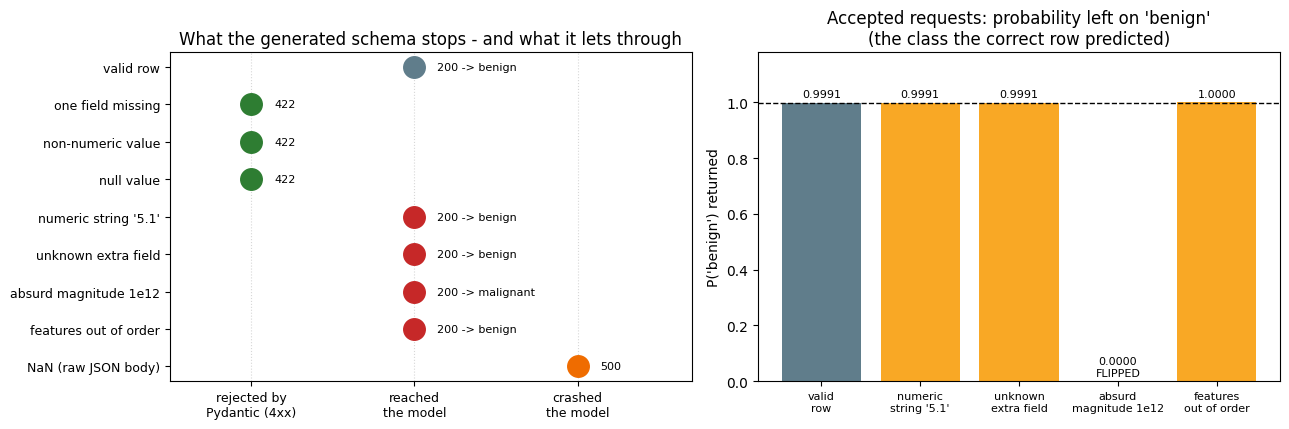

request shape            status   answer
valid row                200      benign @ 0.9991
one field missing        422      rejected by the schema
non-numeric value        422      rejected by the schema
null value               422      rejected by the schema
numeric string '5.1'     200      benign @ 0.9991
unknown extra field      200      benign @ 0.9991
absurd magnitude 1e12    200      malignant @ 1.0000
features out of order    200      benign @ 1.0000
NaN (raw JSON body)      500      500 - the model raised

Accepted without complaint: 5 of 9 requests; 1 of those returned a different class than the correct row.


In [7]:
# WHAT: push eight shapes of request through the generated schema and draw where
# each one ended up, then show what the endpoint answered for the ones it accepted.
# WHY: the previous notebook measured the same battery against a hand-written Flask
# validator. Pydantic replaces that code with a type hint - this figure is the
# evidence for exactly what the type hint does and does not buy you.
import matplotlib.pyplot as plt

# raise_server_exceptions=False makes TestClient report a 500 the way uvicorn would,
# instead of re-raising the model's exception into the notebook.
probe = TestClient(fmod.app, raise_server_exceptions=False)

values = list(card["sample_input"])
valid_payload = dict(zip(fmod.FIELD_ORDER, values))
battery = [
    ("valid row",             valid_payload),
    ("one field missing",     dict(list(valid_payload.items())[:-1])),
    ("non-numeric value",     {**valid_payload, fmod.FIELD_ORDER[0]: "big"}),
    ("null value",            {**valid_payload, fmod.FIELD_ORDER[0]: None}),
    ("numeric string '5.1'",  {**valid_payload, fmod.FIELD_ORDER[0]: str(values[0])}),
    ("unknown extra field",   {**valid_payload, "surprise": 1.0}),
    ("absurd magnitude 1e12", {**valid_payload, fmod.FIELD_ORDER[0]: 1e12}),
    ("features out of order", dict(zip(fmod.FIELD_ORDER, values[1:] + values[:1]))),
    ("NaN (raw JSON body)",   None),   # json.dumps emits a bare NaN token; JSON parsers accept it
]

rows = []
for name, body in battery:
    if body is None:
        raw = json.dumps({**valid_payload, fmod.FIELD_ORDER[0]: float("nan")})
        resp = probe.post("/predict", content=raw, headers={"Content-Type": "application/json"})
    else:
        resp = probe.post("/predict", json=body)
    out = resp.json() if resp.status_code == 200 else {}
    rows.append((name, resp.status_code, out.get("prediction"), out.get("probabilities", {})))

# The class the CORRECT request predicted - the reference every accepted answer is read against.
reference_class = rows[0][2]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

ax = axes[0]
LANE = {4: 0, 2: 1, 5: 2}
for y, (name, code, pred, _probs) in enumerate(rows):
    family = code // 100
    if family == 4:
        colour = "#2e7d32"                       # Pydantic rejected it: the model never ran
    elif family == 5:
        colour = "#ef6c00"                       # accepted, then the model raised
    else:
        colour = "#607d8b" if name == "valid row" else "#c62828"
    ax.scatter([LANE[family]], [y], s=240, color=colour, zorder=3)
    ax.text(LANE[family] + 0.14, y, f"{code}" + (f" -> {pred}" if pred else ""),
            va="center", fontsize=8)
ax.set_yticks(range(len(rows)))
ax.set_yticklabels([r[0] for r in rows], fontsize=9)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["rejected by\nPydantic (4xx)", "reached\nthe model", "crashed\nthe model"],
                   fontsize=9)
ax.set_xlim(-0.5, 2.7)
ax.invert_yaxis()
ax.grid(axis="x", ls=":", alpha=0.5)
ax.set_title("What the generated schema stops - and what it lets through")

# Right panel: for every ACCEPTED request, how much probability is still on the class
# the correct row predicted. A bar that collapses is a silently changed answer.
ax = axes[1]
accepted = [(n, pred, probs) for n, code, pred, probs in rows if code == 200]
heights = [probs.get(reference_class, 0.0) for _n, _p, probs in accepted]
colours = ["#607d8b" if n == "valid row" else ("#c62828" if p != reference_class else "#f9a825")
           for n, p, _probs in accepted]
ax.bar(range(len(accepted)), heights, color=colours)
for i, ((name, pred, _probs), h) in enumerate(zip(accepted, heights)):
    note = f"{h:.4f}" + ("\nFLIPPED" if pred != reference_class else "")
    ax.text(i, h + 0.02, note, ha="center", fontsize=8)
ax.axhline(heights[0], ls="--", lw=1, color="black")
ax.set_xticks(range(len(accepted)))
ax.set_xticklabels([n.replace(" ", "\n", 1) for n, _p, _probs in accepted], fontsize=8)
ax.set_ylim(0, 1.18)
ax.set_ylabel(f"P('{reference_class}') returned")
ax.set_title(f"Accepted requests: probability left on '{reference_class}'\n"
             f"(the class the correct row predicted)")

plt.tight_layout()
plt.show()

# Same result as text - the picture must never be the only record.
print(f"{'request shape':<24} {'status':<8} answer")
for name, code, pred, probs in rows:
    if code == 200:
        answer = f"{pred} @ {max(probs.values()):.4f}"
    else:
        answer = {4: "rejected by the schema", 5: "500 - the model raised"}[code // 100]
    print(f"{name:<24} {code:<8} {answer}")
print(f"\nAccepted without complaint: {len(accepted)} of {len(rows)} requests; "
      f"{sum(1 for _n, p, _q in accepted if p != reference_class)} of those returned a "
      f"different class than the correct row.")


**Reading the figure.** *Left:* nine request shapes — the eight the Flask notebook sent, plus a
numeric string — now travelling through the generated Pydantic schema. Three are rejected
before any of our code runs (green, `422`); that is the type hint doing the entire job of
`validate_input`. The middle lane is the part to stare at: a **numeric string**, an **unknown extra
field**, an **absurd magnitude** and **features supplied in the wrong order** all reach the model
with `200`. Pydantic coerces `"5.1"` to a float by design, ignores unknown keys by default, and
has no opinion about which values are plausible or which order they arrive in. `NaN` is a
perfectly valid float, so it is accepted too — and becomes a `500` inside scikit-learn.

*Right:* for each accepted request, how much probability the endpoint left on the class the
correct row predicted. Four bars stay at the top, so the answer *looks* untouched. The
`1e12` bar drops to `0.0000` and is marked FLIPPED: that request was accepted with `200`
and came back as the opposite class at full confidence, with nothing in the response
admitting anything was odd. **A schema decides whether a request is well-formed, never
whether it is true** — the Ariane 5 point from the top of this notebook, reproduced on your
own endpoint in nine requests. (Your own portfolio model may flip on a different row; the
lane it lands in will not change.)

## 💬 Discuss

We now have two services — Flask in the previous notebook, FastAPI here — serving **the same artifact**, so every difference you observed belongs to the serving layer. The Flask app needed a hand-written `validate_input`; this one deleted it and got `422` responses from a type hint.

1. FastAPI generated a 30-field schema and validated it without a line of validation code. What did that cost? Name something the hand-written Flask validator could express that the generated Pydantic schema cannot, and decide whether you would miss it.
2. `/model-info` reports `"is_fallback": true` — the service is publicly admitting it is serving a course stand-in rather than a real model. Should a production endpoint expose that? Argue both sides: the on-call engineer's and the security reviewer's.
3. The notebook warns that a blocking `predict()` inside `async def` blocks the event loop, so `async` alone buys no concurrency for CPU-bound inference. Given that, is FastAPI actually the right choice for a CPU-only sklearn model, or are you choosing it for the docs and the validation? Say what you would need to measure to settle it.

## 7. Flask vs FastAPI Decision Table

| Scenario | Choose |
|---|---|
| Team already uses Flask, simple API | Flask |
| Need auto-generated docs for a frontend team | FastAPI |
| High concurrent I/O-bound traffic | FastAPI (async) |
| Integrating into an existing Django codebase | Flask |
| New greenfield ML microservice | FastAPI |
| Strict request/response type safety | FastAPI (Pydantic) |

## 8. Summary

In this notebook you:
- Loaded your **portfolio artifact plus its card** — no training, the deployment job starts after training ends
- Generated `PredictRequest` from `model_card.json` with `create_model`, so the API contract follows the model
- Built three async FastAPI endpoints: `/health`, `/model-info`, `/predict`
- Tested the app in-notebook using `TestClient` — no uvicorn process needed
- Inspected the auto-generated OpenAPI schema from `/openapi.json` and saw your own feature names in it

FastAPI's key insight: **write Python type hints once, get validation + serialization + documentation for free.** The deployment insight stacked on top: **derive those type hints from the artifact**, and the documentation can never describe a model you are not actually serving.

**Next:** Unit 4 takes these same two files — artifact and card — and copies them into a Docker image.

## Self-Check (answer before scrolling up)

1. **What does Pydantic do when a required field is missing from the request body?** What HTTP status code does FastAPI return automatically?
2. **Why does this notebook refuse to put `ge=0` on the generated fields?** Name a feature type that would break under it.
3. **What is the `/docs` endpoint and how does it help during development?** Name one thing you can do there that you can't do with just curl.
4. **`/model-info` reports `is_fallback`. Why would a production service want to expose that?**
5. **When would you choose Flask instead of FastAPI?** Give a concrete real-world scenario.

## ⚠️ Where this breaks

- **`async def` around a blocking call is worse than useless.** sklearn's `predict()` holds the event loop for its whole duration, so a single slow request stalls every other request in that worker. FastAPI runs a plain `def` endpoint in a threadpool and would have been the safer choice here; we used `async def` to show the syntax. **Do not copy this pattern into a CPU-bound service without changing it.**
- **The schema validates types, never semantics.** Ariane 5 is the extreme version: a value that is a perfectly valid float and catastrophically out of range. Pydantic will not save you from that, and — as section 3 argues — adding blanket range constraints creates the opposite failure, rejecting legitimate requests. Range checking belongs where you can justify the ranges: in the card, per model.
- **Auto-generated docs are auto-generated *from the schema*, not from reality.** `/docs` will confidently describe an endpoint whose model was replaced by a different artifact ten minutes ago. It is documentation of the contract, not evidence about the deployment. `/model-info` is what tells you what is live — and only because it reads the card at import.
- **`TestClient` is not concurrency.** It exercises the same code path uvicorn would, one request at a time, in-process. Nothing here demonstrates the async advantage, because nothing here is concurrent.
- **The assumption that must hold:** field-name slugging is stable. `api_field()` turns `mean radius` into `mean_radius`. Two training columns that slug to the same name (`"n items"` and `"n-items"`) would silently collide, and a feature renamed upstream silently changes your public API. If your feature names come from a data team you do not control, pin them in the card and fail loudly on change.
- **The cheaper alternative.** One model, one internal caller, a team already fluent in Flask: the previous notebook's service is finished, tested and boring. FastAPI earns its place when the schema is complex, the callers are external, or the documentation has to be trustworthy without a human maintaining it.

## 📚 References

1. Fielding, R. T. (2000). *Architectural Styles and the Design of Network-based Software Architectures* (Ch. 5: REST). PhD dissertation, University of California, Irvine.
2. Olston, C., Fiedel, N., Gorovoy, K., et al. (2017). *TensorFlow-Serving: Flexible, High-Performance ML Serving*. NeurIPS Workshop on ML Systems. <https://arxiv.org/abs/1712.06139>
3. Shankar, S., Garcia, R., Hellerstein, J. M., & Parameswaran, A. G. (2022). *Operationalizing Machine Learning: An Interview Study*. arXiv. <https://arxiv.org/abs/2209.09125>
4. Mitchell, M., Wu, S., Zaldivar, A., Barnes, P., Vasserman, L., Hutchinson, B., Spitzer, E., Raji, I. D., & Gebru, T. (2018). *Model Cards for Model Reporting*. FAT\* 2019. <https://arxiv.org/abs/1810.03993> — the documentation standard `model_card.json` descends from, and the reason a card rather than the handler code is allowed to be the single source of truth about what is deployed.
5. Hou, X., Zhao, Y., Wang, S., & Wang, H. (2025). *Model Context Protocol (MCP): Landscape, Security Threats, and Future Research Directions*. arXiv. <https://arxiv.org/abs/2503.23278> — the 2025 standardization of typed, discoverable interfaces between models and external tools or resources, studied from both an architectural and a security angle. The discipline is the one on this page — declare the schema, validate at the boundary — and the security section is what a declared interface exposes once a model, not a person, is the caller.
